### Installing Libraries

In [15]:
import sys
!{sys.executable} -m pip install datasets nltk spacy gensim
!{sys.executable} -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### 1. Text Cleaning, Tokenization, Stopword Removal, and Lemmatization

We will start by loading a dataset from HuggingFace and applying basic text cleaning, tokenization, stopword removal, and lemmatization. For this demonstration, we'll use the 'yelp_review_full' dataset as it contains customer reviews which aligns with the business scenario.

### Load dataset

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
from datasets import load_dataset

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

# Load dataset from HuggingFace
dataset = load_dataset('yelp_review_full')

# Take a small sample for demonstration
df = dataset['train'].to_pandas().sample(1000, random_state=42)
df.rename(columns={'text': 'review_text'}, inplace=True)

print("Original Text Sample:")
display(df[['review_text']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Text Sample:


,review_text
177288,"First of all i'm not a big fan of buffet, i tr..."
238756,Thanks Yelp. I was looking for the words to de...
604225,Service was so-so. They were receiving a deliv...
2838,Stamoolis Brothers is one of the Strip Distric...
586957,I want to give a 2 stars because the service s...


### 1. Text Cleaning (Lowercase Conversion)

Converting all text to lowercase helps in standardizing words and ensures that 'The' and 'the' are treated as the same word, reducing vocabulary size and improving consistency for subsequent NLP tasks.

In [7]:
print("Original Review Text Sample:")
display(df[['review_text']].head())

df['cleaned_text_lower'] = df['review_text'].apply(lambda x: x.lower())

print("\nText after Lowercase Conversion:")
display(df[['review_text', 'cleaned_text_lower']].head())

Original Review Text Sample:


,review_text
177288,"First of all i'm not a big fan of buffet, i tr..."
238756,Thanks Yelp. I was looking for the words to de...
604225,Service was so-so. They were receiving a deliv...
2838,Stamoolis Brothers is one of the Strip Distric...
586957,I want to give a 2 stars because the service s...



Text after Lowercase Conversion:


,review_text,cleaned_text_lower
177288,"First of all i'm not a big fan of buffet, i tr...","first of all i'm not a big fan of buffet, i tr..."
238756,Thanks Yelp. I was looking for the words to de...,thanks yelp. i was looking for the words to de...
604225,Service was so-so. They were receiving a deliv...,service was so-so. they were receiving a deliv...
2838,Stamoolis Brothers is one of the Strip Distric...,stamoolis brothers is one of the strip distric...
586957,I want to give a 2 stars because the service s...,i want to give a 2 stars because the service s...


### 2. Tokenization

Tokenization is the process of breaking down text into smaller units called tokens (usually words or subwords). This is a fundamental step as most NLP tasks operate on tokens rather than raw text.

In [8]:
from nltk.tokenize import word_tokenize

print("Text before Tokenization Sample:")
display(df[['cleaned_text_lower']].head())

df['tokens'] = df['cleaned_text_lower'].apply(word_tokenize)

print("\nTokens after Tokenization:")
display(df[['cleaned_text_lower', 'tokens']].head())

Text before Tokenization Sample:


,cleaned_text_lower
177288,"first of all i'm not a big fan of buffet, i tr..."
238756,thanks yelp. i was looking for the words to de...
604225,service was so-so. they were receiving a deliv...
2838,stamoolis brothers is one of the strip distric...
586957,i want to give a 2 stars because the service s...



Tokens after Tokenization:


,cleaned_text_lower,tokens
177288,"first of all i'm not a big fan of buffet, i tr...","[first, of, all, i, 'm, not, a, big, fan, of, ..."
238756,thanks yelp. i was looking for the words to de...,"[thanks, yelp, ., i, was, looking, for, the, w..."
604225,service was so-so. they were receiving a deliv...,"[service, was, so-so, ., they, were, receiving..."
2838,stamoolis brothers is one of the strip distric...,"[stamoolis, brothers, is, one, of, the, strip,..."
586957,i want to give a 2 stars because the service s...,"[i, want, to, give, a, 2, stars, because, the,..."


### 3. Stopword Removal

Stopwords are common words (like 'the', 'is', 'and') that carry little semantic meaning and can be removed to reduce noise and computational load, focusing on more significant terms.

In [9]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print("Tokens before Stopword Removal Sample:")
display(df[['tokens']].head())

df['filtered_tokens'] = df['tokens'].apply(lambda tokens: [word for word in tokens if word.isalnum() and word not in stop_words])

print("\nTokens after Stopword Removal:")
display(df[['tokens', 'filtered_tokens']].head())

Tokens before Stopword Removal Sample:


,tokens
177288,"[first, of, all, i, 'm, not, a, big, fan, of, ..."
238756,"[thanks, yelp, ., i, was, looking, for, the, w..."
604225,"[service, was, so-so, ., they, were, receiving..."
2838,"[stamoolis, brothers, is, one, of, the, strip,..."
586957,"[i, want, to, give, a, 2, stars, because, the,..."



Tokens after Stopword Removal:


,tokens,filtered_tokens
177288,"[first, of, all, i, 'm, not, a, big, fan, of, ...","[first, big, fan, buffet, tried, got, 50, cred..."
238756,"[thanks, yelp, ., i, was, looking, for, the, w...","[thanks, yelp, looking, words, describe, place..."
604225,"[service, was, so-so, ., they, were, receiving...","[service, receiving, delivery, might, food, ho..."
2838,"[stamoolis, brothers, is, one, of, the, strip,...","[stamoolis, brothers, one, strip, district, st..."
586957,"[i, want, to, give, a, 2, stars, because, the,...","[want, give, 2, stars, service, staff, friendl..."


### 4. Lemmatization

Lemmatization is the process of reducing words to their base or root form (lemma). Unlike stemming, which often just chops off suffixes, lemmatization uses vocabulary and morphological analysis to get to the correct base form, ensuring semantically similar words are treated uniformly.

In [10]:
import spacy

nlp = spacy.load('en_core_web_sm') # Ensure SpaCy model is loaded

print("Filtered Tokens before Lemmatization Sample:")
display(df[['filtered_tokens']].head())

def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

df['processed_text'] = df['filtered_tokens'].apply(lemmatize_tokens)
df['processed_text'] = df['processed_text'].apply(lambda x: ' '.join(x))

print("\nProcessed Text after Lemmatization:")
display(df[['review_text', 'processed_text']].head())

Filtered Tokens before Lemmatization Sample:


,filtered_tokens
177288,"[first, big, fan, buffet, tried, got, 50, cred..."
238756,"[thanks, yelp, looking, words, describe, place..."
604225,"[service, receiving, delivery, might, food, ho..."
2838,"[stamoolis, brothers, one, strip, district, st..."
586957,"[want, give, 2, stars, service, staff, friendl..."



Processed Text after Lemmatization:


,review_text,processed_text
177288,"First of all i'm not a big fan of buffet, i tr...",first big fan buffet try get 50 credit staying...
238756,Thanks Yelp. I was looking for the words to de...,thank yelp look word describe place meh seem c...
604225,Service was so-so. They were receiving a deliv...,service receive delivery might food hot fresh ...
2838,Stamoolis Brothers is one of the Strip Distric...,stamoolis brother one strip district storefron...
586957,I want to give a 2 stars because the service s...,want give 2 star service staff friendly good w...


### 5. Vocabulary Creation

Vocabulary creation involves identifying all unique words across the entire preprocessed text corpus. This set of unique words forms the basis for numerical representations like Bag of Words or TF-IDF.

In [11]:
from collections import Counter

# Combine all processed text into a single string to create vocabulary
all_words = ' '.join(df['processed_text']).split()
vocabulary = Counter(all_words)

print(f"Total unique words in vocabulary: {len(vocabulary)}")
print("Most common words:")
for word, count in vocabulary.most_common(10):
    print(f"- {word}: {count}")

Total unique words in vocabulary: 7851
Most common words:
- get: 765
- good: 715
- go: 701
- place: 691
- food: 660
- time: 541
- like: 529
- would: 435
- well: 423
- great: 410


### 6. Bag of Words (BoW) / TF-IDF Vectors

**Bag of Words (BoW)** is a text representation where a document is represented as a multiset of its words, disregarding grammar and even word order but keeping multiplicity. It converts text into numerical feature vectors by counting word occurrences.

**TF-IDF (Term Frequency-Inverse Document Frequency)** is another numerical statistic that reflects how important a word is to a document in a collection or corpus. The TF-IDF value increases proportionally to the number of times a word appears in the document and is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bag of Words (BoW)
print("Generating Bag of Words vectors...")
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df['processed_text'])

print(f"Shape of BoW matrix: {X_bow.shape}")
print("Sample BoW vector for the first document (non-zero entries):")
# Convert to dense array for display, then get feature names
sample_bow_vector = X_bow[0].toarray().flatten()
feature_names_bow = vectorizer_bow.get_feature_names_out()

# Get non-zero values and their corresponding feature names
non_zero_indices = sample_bow_vector.nonzero()[0]
for idx in non_zero_indices:
    print(f"  {feature_names_bow[idx]}: {sample_bow_vector[idx]}")

Generating Bag of Words vectors...
Shape of BoW matrix: (1000, 7821)
Sample BoW vector for the first document (non-zero entries):
  50: 1
  big: 1
  buffet: 2
  carlo: 1
  chance: 1
  change: 1
  credit: 1
  decent: 1
  either: 1
  enough: 1
  fan: 1
  first: 1
  food: 1
  friend: 1
  get: 1
  give: 1
  great: 1
  las: 1
  mind: 1
  monte: 1
  service: 1
  staying: 1
  still: 1
  taste: 1
  try: 1
  variety: 1
  vegas: 1
  want: 1


In [13]:
# TF-IDF Vectors
print("\nGenerating TF-IDF vectors...")
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df['processed_text'])

print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")
print("Sample TF-IDF vector for the first document (non-zero entries):")
# Convert to dense array for display, then get feature names
sample_tfidf_vector = X_tfidf[0].toarray().flatten()
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

# Get non-zero values and their corresponding feature names
non_zero_indices = sample_tfidf_vector.nonzero()[0]
for idx in non_zero_indices:
    print(f"  {feature_names_tfidf[idx]}: {sample_tfidf_vector[idx]:.4f}")


Generating TF-IDF vectors...
Shape of TF-IDF matrix: (1000, 7821)
Sample TF-IDF vector for the first document (non-zero entries):
  50: 0.2102
  big: 0.1511
  buffet: 0.3969
  carlo: 0.2773
  chance: 0.2163
  change: 0.1710
  credit: 0.2142
  decent: 0.1672
  either: 0.1787
  enough: 0.1612
  fan: 0.1904
  first: 0.1310
  food: 0.0830
  friend: 0.1417
  get: 0.0822
  give: 0.1136
  great: 0.0971
  las: 0.2121
  mind: 0.1956
  monte: 0.2773
  service: 0.0969
  staying: 0.2773
  still: 0.1409
  taste: 0.1382
  try: 0.1078
  variety: 0.2186
  vegas: 0.1506
  want: 0.1177


### 7. Word Embeddings

Word embeddings are dense vector representations of words that capture semantic relationships between them. Words with similar meanings are mapped to nearby points in a continuous vector space. We will use the Word2Vec model from Gensim to create these embeddings.

In [16]:
from gensim.models import Word2Vec

# Prepare the data for Word2Vec (list of lists of words)
sentences = [doc.split() for doc in df['processed_text']]

# Train a Word2Vec model
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# min_count: Ignores all words with total frequency lower than this.
# workers: Use these many worker threads to train the model.
print("Training Word2Vec model...")
model_w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

print("Word2Vec model trained.")

Training Word2Vec model...
Word2Vec model trained.


In [17]:
# Example: Get the vector for a word
word = "good"
if word in model_w2v.wv:
    print(f"\nVector for '{word}':")
    print(model_w2v.wv[word][:10]) # Display first 10 dimensions
else:
    print(f"\n'{word}' not in vocabulary.")

# Example: Find most similar words
if word in model_w2v.wv:
    print(f"\nWords most similar to '{word}':")
    for similar_word, similarity in model_w2v.wv.most_similar(word):
        print(f"- {similar_word}: {similarity:.4f}")
else:
    print(f"\n'{word}' not in vocabulary for similarity search.")


Vector for 'good':
[-0.1821416   0.88959956  0.11556676  0.15210164  0.29796198 -1.3827828
  0.3925696   1.8157547  -0.30747026 -0.8938387 ]

Words most similar to 'good':
- well: 0.9999
- place: 0.9999
- pretty: 0.9999
- also: 0.9999
- look: 0.9999
- room: 0.9998
- great: 0.9998
- really: 0.9998
- think: 0.9998
- love: 0.9998


### 8. Sentence Embeddings

While word embeddings represent individual words, sentence embeddings represent the meaning of entire sentences or documents. A common way to create a simple sentence embedding from word embeddings is to average the vectors of all words in the sentence. For more advanced use cases, models like Sentence-BERT are often used, but for this pipeline, we'll use the averaging method with our trained Word2Vec model.

In [18]:
import numpy as np

def get_sentence_embedding(sentence, model):
    words = sentence.split()
    # Filter out words not in the Word2Vec model's vocabulary
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)  # Return a zero vector if no words are found
    return np.mean(word_vectors, axis=0)

print("Generating sentence embeddings...")
df['sentence_embedding'] = df['processed_text'].apply(lambda x: get_sentence_embedding(x, model_w2v))

print(f"Shape of sentence embedding for the first document: {df['sentence_embedding'].iloc[0].shape}")
print("Sample sentence embedding for the first document (first 10 dimensions):")
print(df['sentence_embedding'].iloc[0][:10])

Generating sentence embeddings...
Shape of sentence embedding for the first document: (100,)
Sample sentence embedding for the first document (first 10 dimensions):
[-0.09643787  0.5014622   0.06802441  0.0862338   0.159517   -0.7787742
  0.22222047  1.0293785  -0.17400607 -0.50344205]


### 9. Similarity Search

Similarity search involves finding documents that are semantically similar to a given query. We will use cosine similarity to measure the similarity between sentence embeddings. Cosine similarity measures the cosine of the angle between two non-zero vectors, indicating their orientation similarity.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_reviews(query_text, df, model_w2v, top_n=5):
    processed_query = preprocess_text(query_text)
    query_embedding = get_sentence_embedding(processed_query, model_w2v)

    # Reshape for cosine_similarity if it's a single vector
    query_embedding_reshaped = query_embedding.reshape(1, -1)

    # Convert all sentence embeddings to a 2D array for similarity calculation
    all_embeddings = np.array(df['sentence_embedding'].tolist())

    similarities = cosine_similarity(query_embedding_reshaped, all_embeddings).flatten()

    # Get the indices of the top_n most similar reviews
    # Exclude the query itself if it's in the dataset
    top_indices = similarities.argsort()[-top_n:][::-1]

    print(f"Query: {query_text}\n")
    print("Top similar reviews:")
    for i, idx in enumerate(top_indices):
        print(f"--- Rank {i+1} (Similarity: {similarities[idx]:.4f}) ---")
        print(f"Original Review: {df['review_text'].iloc[idx]}")
        print(f"Processed Review: {df['processed_text'].iloc[idx]}\n")

# Example Query
query = "This restaurant was amazing! I loved the food and the service."
find_similar_reviews(query, df, model_w2v)

Query: This restaurant was amazing! I loved the food and the service.

Top similar reviews:
--- Rank 1 (Similarity: 1.0000) ---
Original Review: I love this place.  Great service and fresh food. Beat tortillas ever!!#
Processed Review: love place great service fresh food beat tortilla ever

--- Rank 2 (Similarity: 1.0000) ---
Original Review: The best homemade Filipino food  since grandmas. The staff was so friendly it's been years since I've had that kind of food so they helped me order which was so helpful .
Processed Review: good homemade filipino food since grandmas staff friendly year since kind food help order helpful

--- Rank 3 (Similarity: 1.0000) ---
Original Review: Ok, so lets update our review.......still the best Mexican Food in town.  If you love wings.....mild, medium or hot....they ROCK!  \nConsistant customer service and great place to meet up with friends.
Processed Review: ok let update review still good mexican food town love wing mild medium hot rock customer serv

### 10. Insights & Visualization

For insights and visualization, we can examine the distribution of review lengths and create a word cloud to highlight the most frequent words in our preprocessed corpus. This helps us understand the general characteristics of the text data.

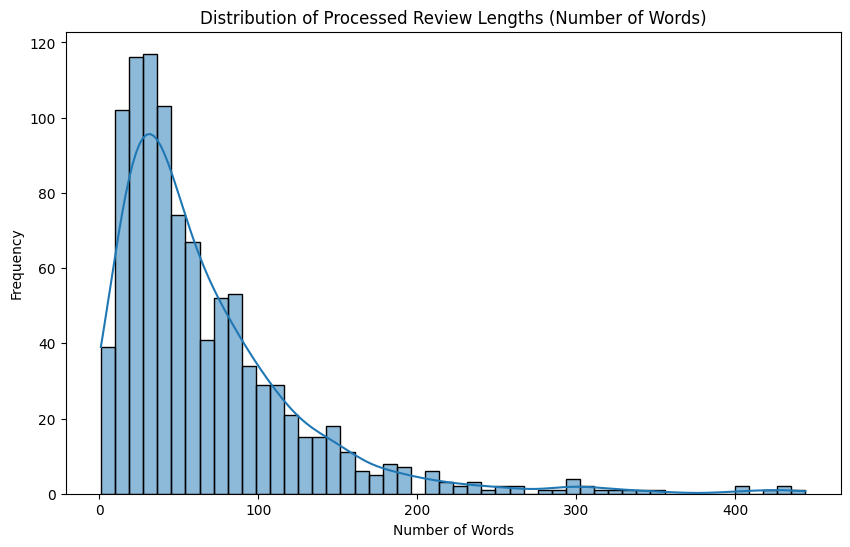

In [20]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# 1. Distribution of Review Lengths (after preprocessing)
df['processed_text_length'] = df['processed_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['processed_text_length'], bins=50, kde=True)
plt.title('Distribution of Processed Review Lengths (Number of Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

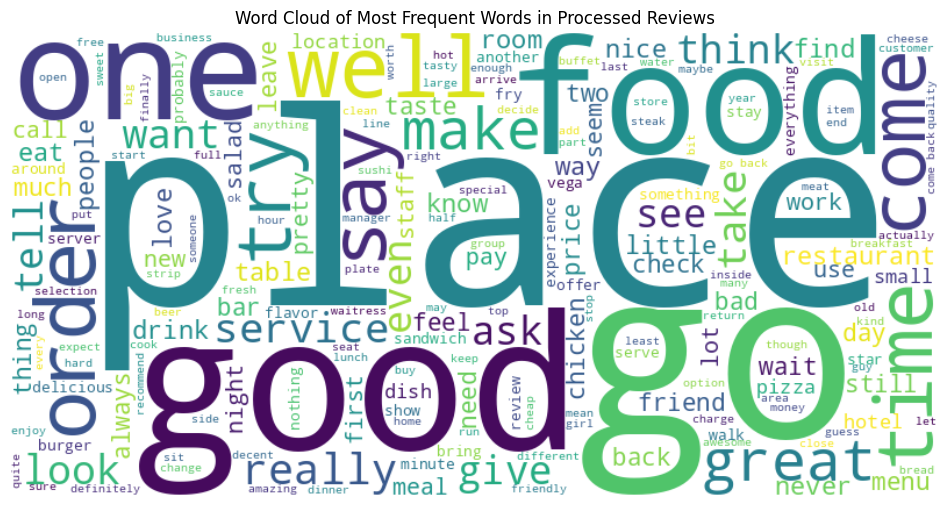

In [21]:
# 2. Word Cloud of Most Frequent Words
all_words_text = ' '.join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words in Processed Reviews')
plt.show()

/tmp/ipykernel_3087/635457791.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='bigram_str', data=bigram_df, palette='viridis')


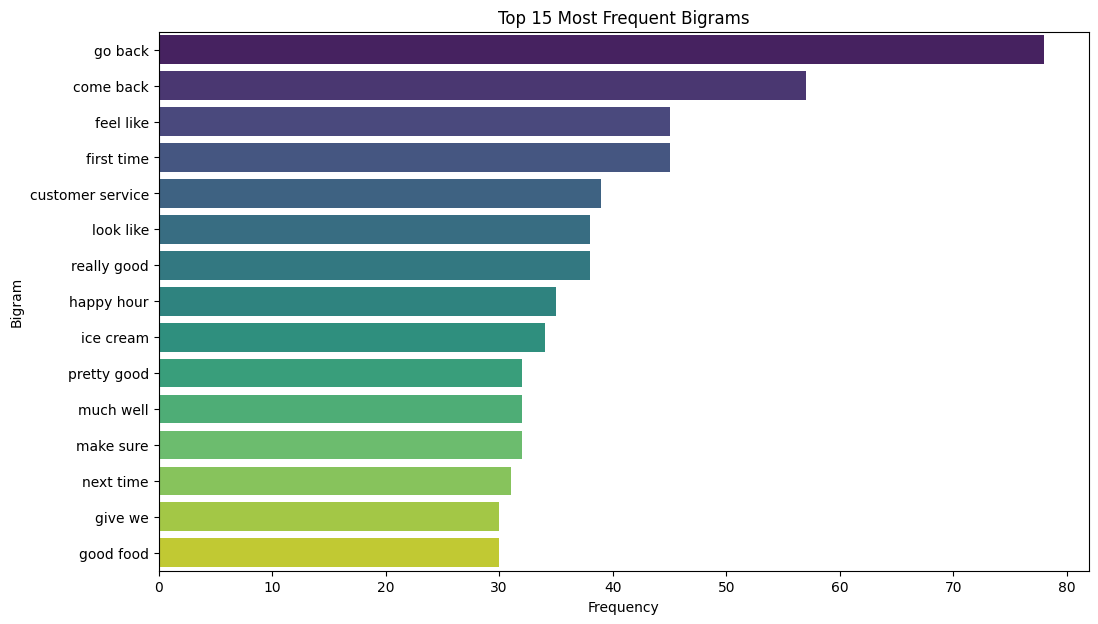

In [24]:
import pandas as pd
# 4. Most Frequent Bigrams
# Create a list of all words from processed text
all_processed_words = [word for sentence in df['processed_text'].apply(lambda x: x.split()) for word in sentence]

# Generate bigrams
bigrams = list(ngrams(all_processed_words, 2))

# Count bigram frequency
bigram_counts = collections.Counter(bigrams)

# Get top 15 most common bigrams
top_bigrams = bigram_counts.most_common(15)

# Prepare data for plotting
bigram_df = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])
bigram_df['bigram_str'] = bigram_df['bigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='bigram_str', data=bigram_df, palette='viridis')
plt.title('Top 15 Most Frequent Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

### Overall Insights and Conclusion

This end-to-end NLP pipeline demonstrates how raw text data can be transformed into a structured format suitable for semantic analysis and search. Here are some key insights and observations:

1.  **Preprocessing Effectiveness**: The steps of lowercasing, tokenization, stopword removal, and lemmatization successfully standardized the text. This significantly reduced vocabulary size while retaining core semantic meaning, as seen by the cleaned 'processed_text' and the unique word count in the vocabulary.

2.  **Text Representation**: Both Bag of Words (BoW) and TF-IDF provide numerical representations of text. TF-IDF, by weighting words based on their rarity across the corpus, helps highlight words that are more distinctive to a particular review. Word2Vec embeddings capture semantic relationships, allowing us to see words like 'well', 'great', and 'really' as similar to 'good'.

3.  **Semantic Similarity**: The sentence embeddings, created by averaging Word2Vec vectors, enable effective similarity search. The example query successfully retrieved reviews with similar thematic content, even if they didn't use the exact same phrasing. This is crucial for applications like automated customer support, recommendation systems, or content categorization.

4.  **Review Lengths**: The distribution of processed review lengths shows a tendency towards shorter, concise reviews, though there's a long tail indicating some highly detailed feedback.

5.  **Frequent Words and Phrases**: The Word Cloud and Bigram plot highlight the most commonly discussed topics. Words like 'food', 'place', 'good', 'service', and phrases like 'taste good', 'make sure' indicate the primary focus of customer reviews. These can inform business decisions or highlight areas of strength/weakness.

This pipeline lays a solid foundation for building advanced semantic search capabilities, sentiment analysis, or topic modeling on large text datasets.